In [13]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import librosa
import librosa.display
from tqdm import  tqdm
import seaborn as sns

# Exploration of the dataset and preprocessing

## Loading csv files and first preprocessing

In [14]:
d_types={'Id':int, 'sampling_rate':int, 'age':float, 'gender':str, 'ethnicity':str, 'mean_pitch':float, 'max_pitch':float, 'min_pitch':float, 'jitter':float, 'shimmer':float, 'energy':float, 'zcr_mean':float,
       'spectral_centroid_mean':float, 'tempo':str, 'hnr':float, 'num_words':int, 'num_characters':int,
       'num_pauses':int, 'silence_duration':float, 'path':str}

In [15]:
dev_audio = os.listdir(r'data\audios_development')
df_dev = pd.read_csv(r'data\development.csv', index_col='Id', dtype=d_types)
eval_audio = os.listdir(r'data\audios_evaluation')
df_eval = pd.read_csv(r'data\evaluation.csv', index_col='Id', dtype=d_types)
df_csv = pd.concat([df_dev, df_eval], sort=False)

There are no missing values (except for age in the evaluation set) or duplicates

In [16]:
df_csv.isna().any()

sampling_rate             False
age                        True
gender                    False
ethnicity                 False
mean_pitch                False
max_pitch                 False
min_pitch                 False
jitter                    False
shimmer                   False
energy                    False
zcr_mean                  False
spectral_centroid_mean    False
tempo                     False
hnr                       False
num_words                 False
num_characters            False
num_pauses                False
silence_duration          False
path                      False
dtype: bool

In [17]:
df_csv.duplicated().any()

np.False_

In [18]:
df_csv['tempo']=df_csv['tempo'].str.strip('[]').astype(float)

Sampling rate can be removed since it is the same for every sample

In [19]:
df_csv["sampling_rate"].value_counts()

sampling_rate
22050    3624
Name: count, dtype: int64

In [20]:
df_drop = df_csv.drop(columns=['sampling_rate'])

In [21]:
df_drop["ethnicity"].value_counts()

ethnicity
igbo         1313
english       579
spanish       162
arabic        102
mandarin       65
             ... 
serer           1
sicilian        1
wu              1
ogoni           1
sundanese       1
Name: count, Length: 221, dtype: int64

Distribution of age in development set

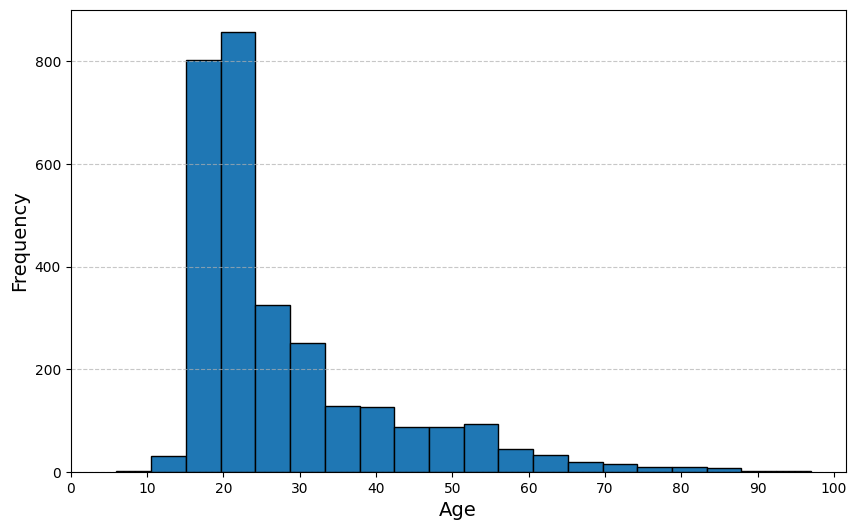

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(df_dev['age'], bins=20, edgecolor='black')
plt.xlabel('Age', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(0,101,10), fontsize=10)
plt.show()

Distribution of number of words in the whole dataset

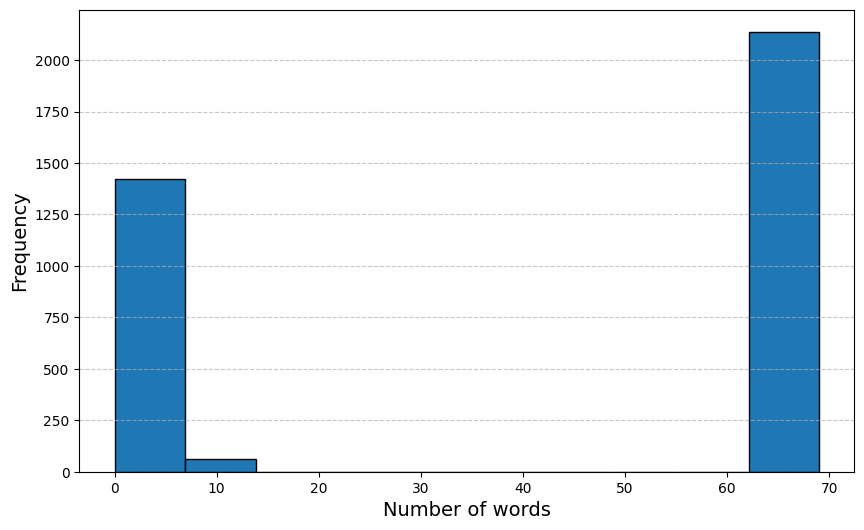

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(df_csv['num_words'], bins=10, edgecolor='black')
plt.xlabel('Number of words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Relations between age and other features

In [24]:
""" 
import seaborn as sns
import matplotlib.pyplot as plt
target='age'
for col in df_drop.select_dtypes(include=['float', 'int']).columns:
    if col != target:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=df_drop[col], y=df_drop[target])
        plt.title(f'Relazione tra {col} e {target}')
        plt.show()
"""


" \nimport seaborn as sns\nimport matplotlib.pyplot as plt\ntarget='age'\nfor col in df_drop.select_dtypes(include=['float', 'int']).columns:\n    if col != target:\n        plt.figure(figsize=(8, 6))\n        sns.scatterplot(x=df_drop[col], y=df_drop[target])\n        plt.title(f'Relazione tra {col} e {target}')\n        plt.show()\n"

## Feature extraction from audios
We extract new audio features from the Log-Mel spectrogram and MFCCs using librosa library

In [25]:
def extract_audio_features(df, phase, representation, n_representation, padding=True):
    # Check if the features file exists
    if padding == False:
        features_file = f"audio_features/{phase}/features_{representation}_{n_representation}.csv"
    else:
        features_file = f"audio_features/{phase}/features_{representation}_{n_representation}_padding.csv"
    if os.path.exists(features_file):
        print(f"Loading existing features from {features_file}...")
        return pd.read_csv(features_file, index_col="Id")

    print(f"Extracting {n_representation} features using {representation}...")

    list_dict_audio_features = []
    
    for file_path in tqdm(df["path"]):
        # Load the audio signal
        y, sr = librosa.load("data/" + file_path)
        
        max_sec = 35
        max_samples = max_sec * sr
        if padding == True:
            if len(y) > max_samples:
                y = y[:max_samples]
            elif len(y) < max_samples:
                y = np.pad(y, (0, max_samples), mode='constant')
    
        # Select representation
        if representation == "mel":
            # Compute mel spectrogram
            spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_representation)
            log_spectrogram = librosa.power_to_db(spectrogram, ref=np.max)
    
            # Extract statistical features
            mean = np.mean(log_spectrogram, axis=1)
            std = np.std(log_spectrogram, axis=1)
    
            id_audio = int(df[df["path"] == file_path].index[0])
    
            dict_freq = {"Id": id_audio}
            for i in range(n_representation):
                dict_freq[f"mean_spect_{i + 1}"] = mean[i]
                dict_freq[f"std_spect_{i + 1}"] = std[i]
    
        elif representation == "mfcc":
            # Compute MFCCs
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_representation)
    
            # Extract statistical features
            mean = np.mean(mfccs, axis=1)
            std = np.std(mfccs, axis=1)
    
            id_audio = int(df[df["path"] == file_path].index[0])
    
            dict_freq = {"Id": id_audio}
            for i in range(n_representation):
                dict_freq[f"mean_mfcc_{i + 1}"] = mean[i]
                dict_freq[f"std_mfcc_{i + 1}"] = std[i]
    
        # Append the dictionary to the list
        list_dict_audio_features.append(dict_freq)

    df_audio = pd.DataFrame(list_dict_audio_features).set_index("Id")

    # Save features to a file
    print(f"Saving extracted features to {features_file}...")
    df_audio.to_csv(features_file)

    return df_audio

In [26]:
""" 
for mel in [20,30,40,50,60]:
    df_audio_dev = extract_audio_features(df_dev,'dev_pad_35',"mel", mel, padding=True)
    df_audio_ev = extract_audio_features(df_eval,'eval_pad_35',"mel", mel, padding=True)

for mfcc in [10,11,12,13,14,15]:
    df_audio_dev = extract_audio_features(df_dev,'dev_pad_35',"mfcc", mfcc, padding=True)
    df_audio_ev = extract_audio_features(df_eval,'eval_pad_35',"mfcc", mfcc, padding=True)
"""

' \nfor mel in [20,30,40,50,60]:\n    df_audio_dev = extract_audio_features(df_dev,\'dev_pad_35\',"mel", mel, padding=True)\n    df_audio_ev = extract_audio_features(df_eval,\'eval_pad_35\',"mel", mel, padding=True)\n\nfor mfcc in [10,11,12,13,14,15]:\n    df_audio_dev = extract_audio_features(df_dev,\'dev_pad_35\',"mfcc", mfcc, padding=True)\n    df_audio_ev = extract_audio_features(df_eval,\'eval_pad_35\',"mfcc", mfcc, padding=True)\n'

## Example of a Log-Mel spectrogram and MFCCs

In [27]:
y, sr = librosa.load(r"data/audios_development/1.wav")

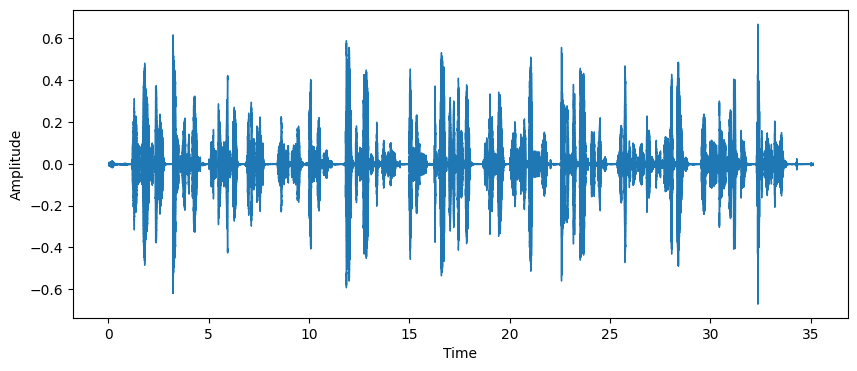

In [28]:
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y=y, sr=sr)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

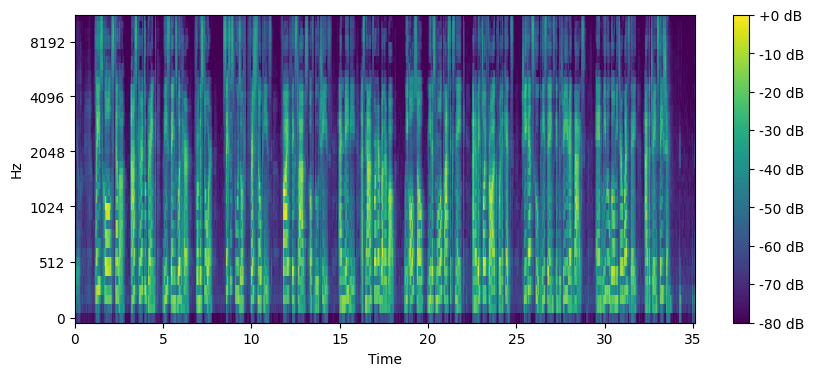

In [29]:
spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40)
log_spectrogram = librosa.power_to_db(spectrogram, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(log_spectrogram, sr=sr, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')

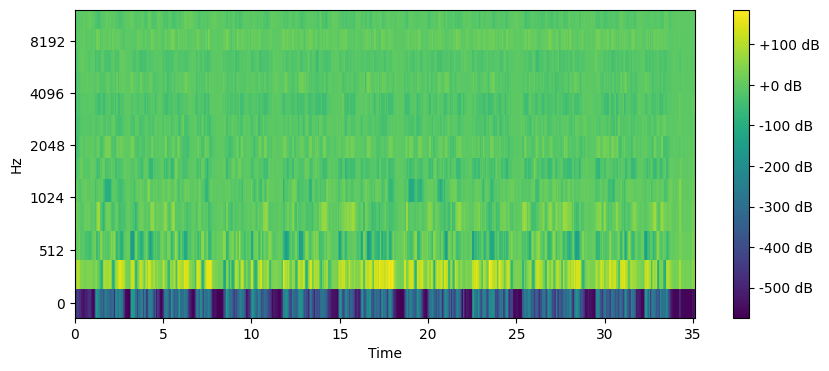

In [30]:
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, sr=sr, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')

## Interactions between gender and other features
We add to our model new features given by the interaction of the cathegorical one "gender" with the numerical features where the division between males and females is significant

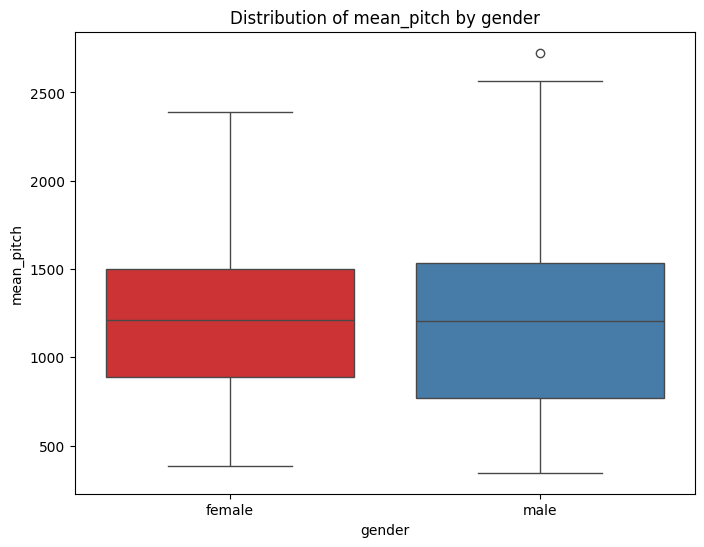

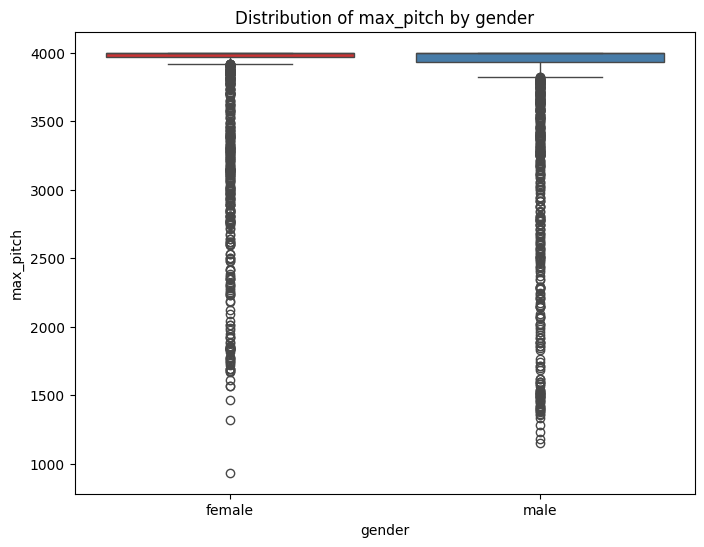

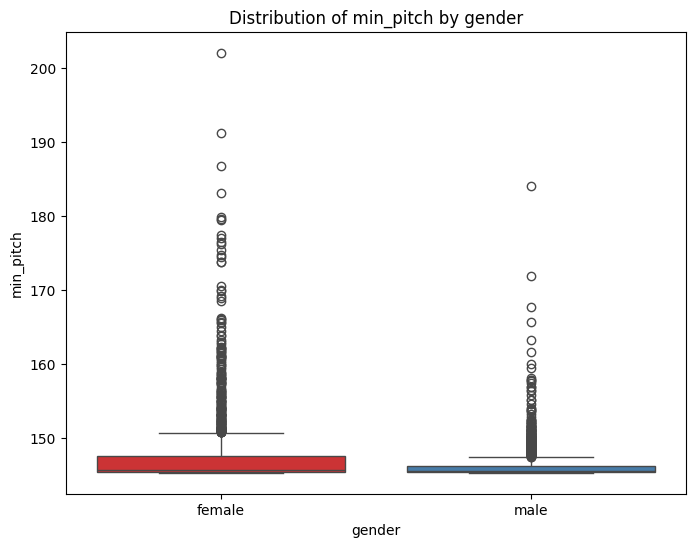

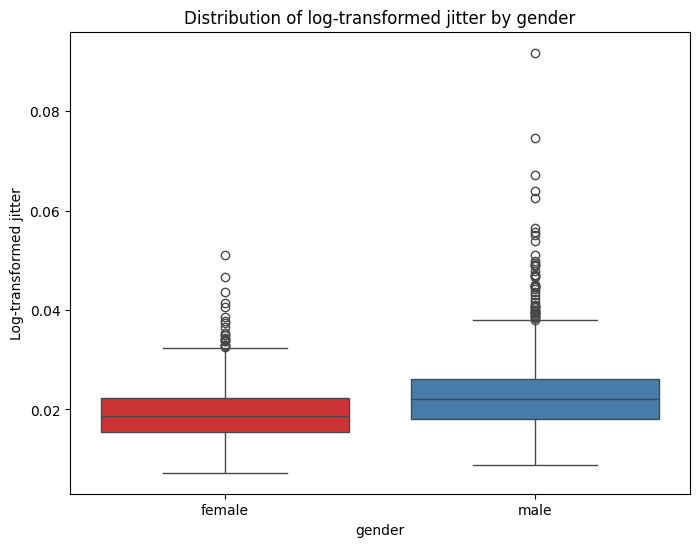

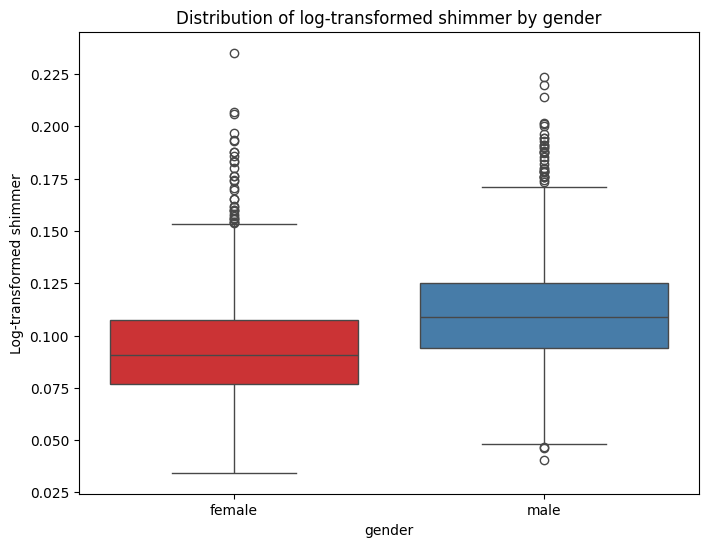

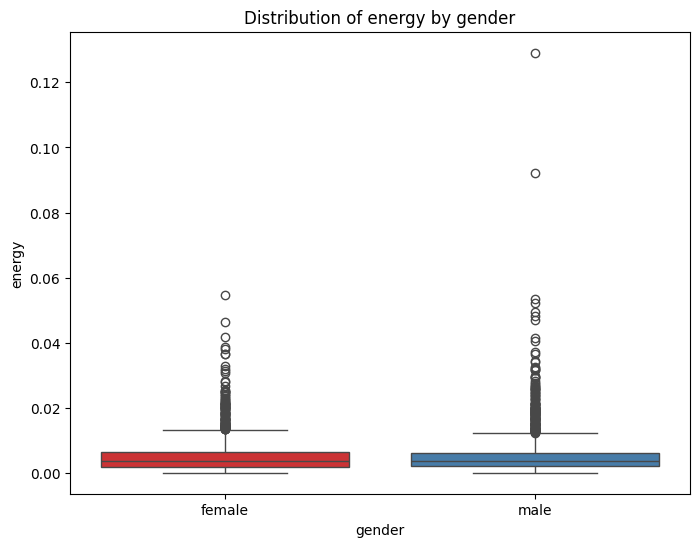

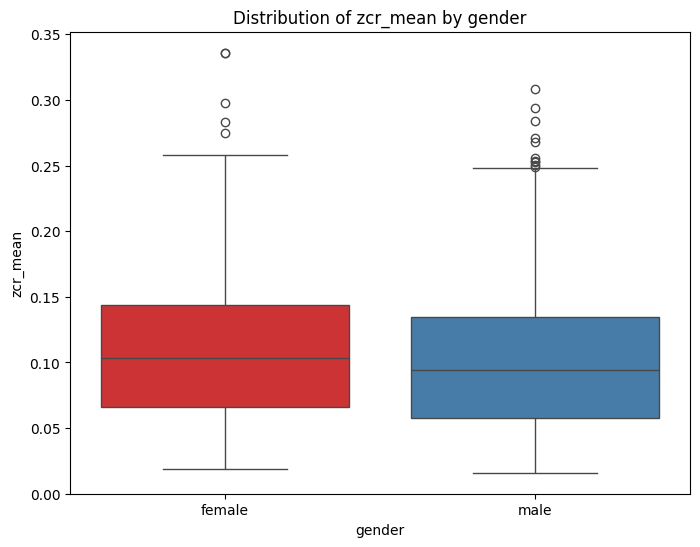

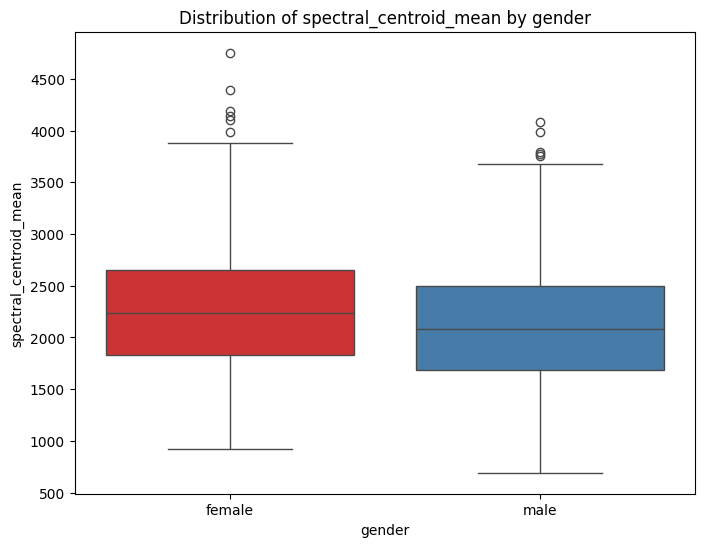

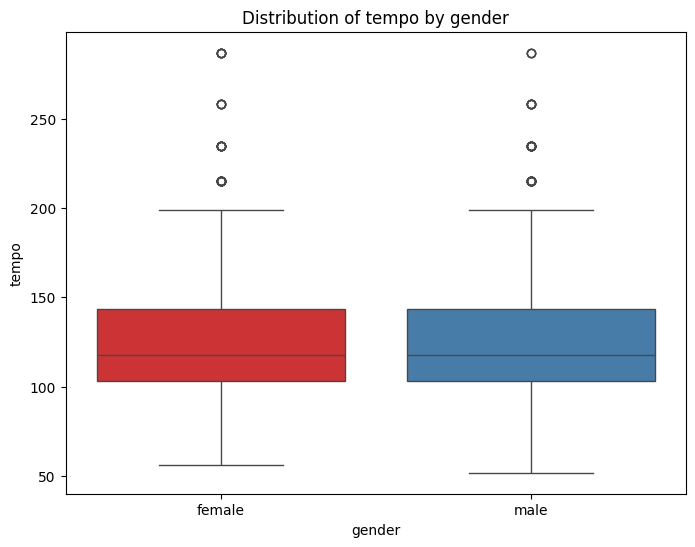

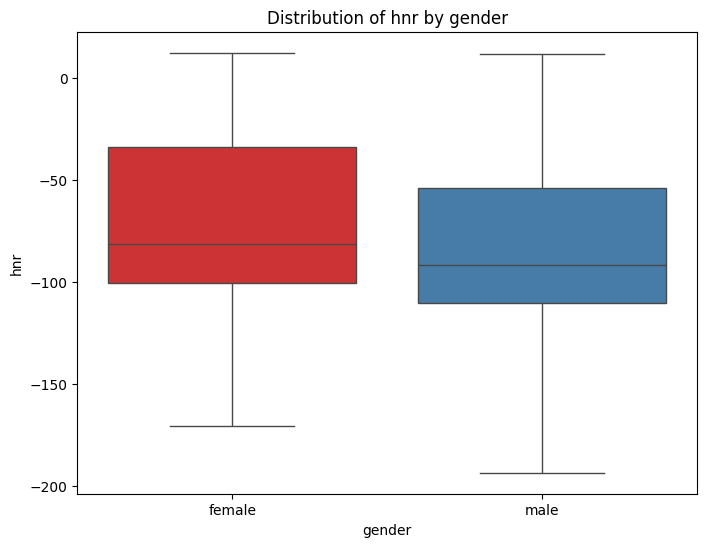

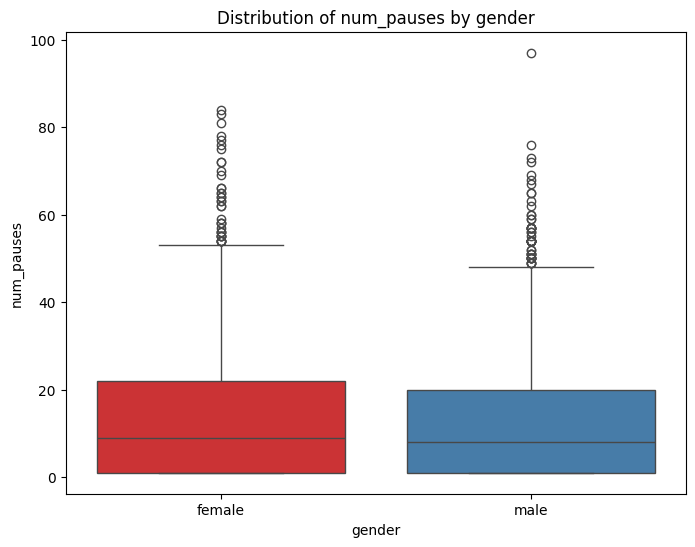

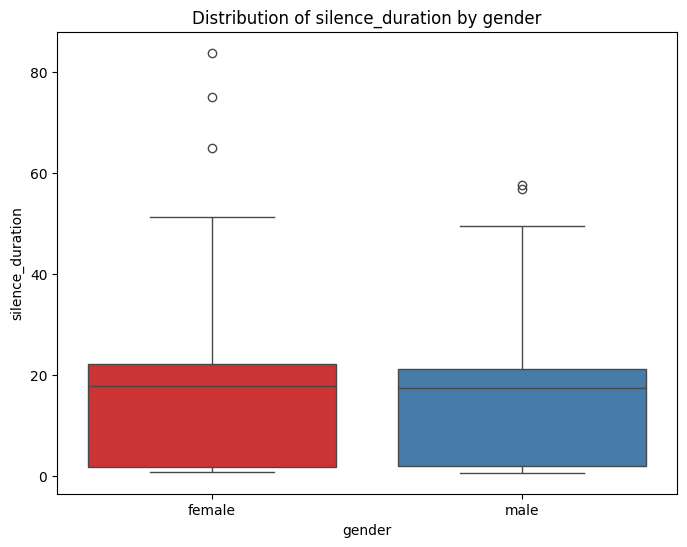

In [31]:
target = 'gender'
for col in df_drop.drop(columns=["num_words", "num_characters"]).select_dtypes(include=['float', 'int']).columns:
    if col in ['shimmer', 'jitter']:  # Applica la scala logaritmica solo a shimmer e jitter
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=df_drop[target], y=np.log1p(df_drop[col]), hue=df_drop["gender"], palette='Set1')
        plt.title(f'Distribution of log-transformed {col} by {target}')
        plt.ylabel(f'Log-transformed {col}')
        plt.show()
    elif col != 'age':  # Altri grafici, esclusa l'età
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=df_drop[target], y=df_drop[col], hue=df_drop["gender"], palette='Set1')
        plt.title(f'Distribution of {col} by {target}')
        plt.show()


In [303]:
df_drop = pd.get_dummies(df_drop, columns=["gender"])

In [304]:
for col in ['spectral_centroid_mean']:
    for gender_col in ['gender_male']:
        df_drop[f"{gender_col}_{col}_interaction"] = df_drop[gender_col] * df_drop[col]
df_drop = df_drop.drop(columns=['gender_male','gender_female'])
df_drop = df_drop.drop(columns=df_drop.columns[df_drop.columns.str.startswith('gender_female')])

## Dataset division into short-samples and long-samples

In [305]:
mask_num_words = (df_drop["num_words"]==69)
df_long = df_drop[mask_num_words]
df_short = df_drop[~mask_num_words]

In [306]:
df_short["ethnicity"].value_counts()

ethnicity
igbo           1310
urhobo           33
igala            26
ibibio           26
congolese        14
yoruba           12
ika              10
obudu            10
indian            4
annang            4
tiv               4
kanuri            4
ikwerre           3
ijaw              3
afemai            3
cameroonian       3
hausa             3
ukwani            3
kaire-kaire       2
fulani            2
ikom              1
okobo             1
ekoi              1
okirika           1
nigerian          1
lokaa             1
ogoni             1
Name: count, dtype: int64

In [307]:
df_long["ethnicity"].value_counts()

ethnicity
english      579
spanish      162
arabic       102
mandarin      65
french        63
            ... 
turkmen        1
serer          1
sicilian       1
wu             1
sundanese      1
Name: count, Length: 200, dtype: int64

In [308]:
df_long["group"] = df_long["ethnicity"].copy()
mask_others = (df_long["ethnicity"]!="english") 
df_long.loc[mask_others, "group"] = "other"

C:\Users\sonia\AppData\Local\Temp\ipykernel_14612\1536768049.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_long["group"] = df_long["ethnicity"].copy()


In [309]:
df_short = df_short.drop(columns="ethnicity")
df_long = df_long.drop(columns="ethnicity")

In [310]:
mask = df_short["age"].isna()
print(f"There are {df_short[~mask].shape[0]} short-samples of development set and {df_short[mask].shape[0]} of evaluation set") 
mask = df_long["age"].isna()
print(f"There are {df_long[~mask].shape[0]} long-samples of development set and {df_long[mask].shape[0]} of evaluation set") 

There are 1223 short-samples of development set and 263 of evaluation set
There are 1710 long-samples of development set and 428 of evaluation set


## Interactions with group in the long-samples subgroup
We add to our model new features given by the interaction of the cathegorical one "group" with the numerical features "silence_duration", "num_pauses" where the division between the groups is significant

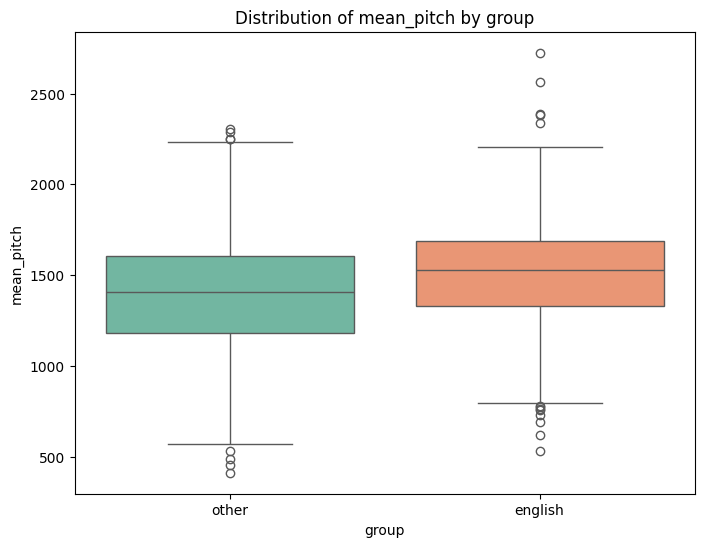

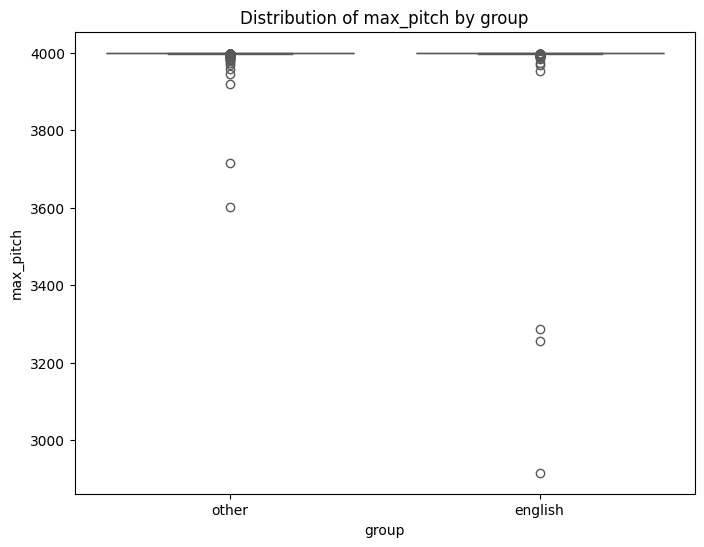

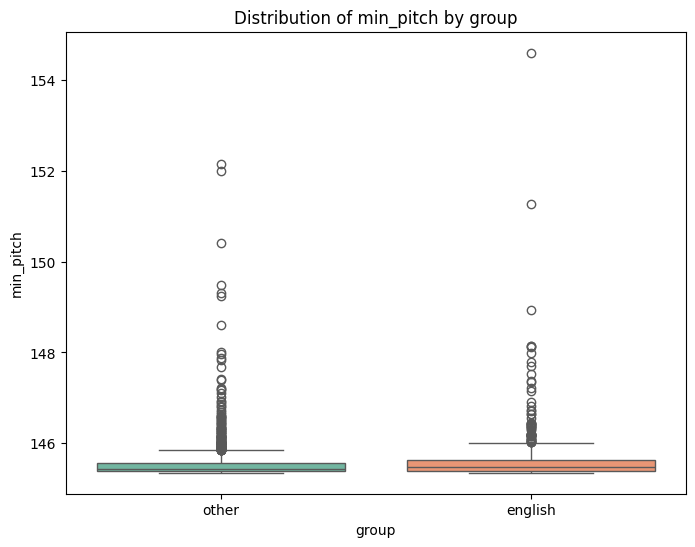

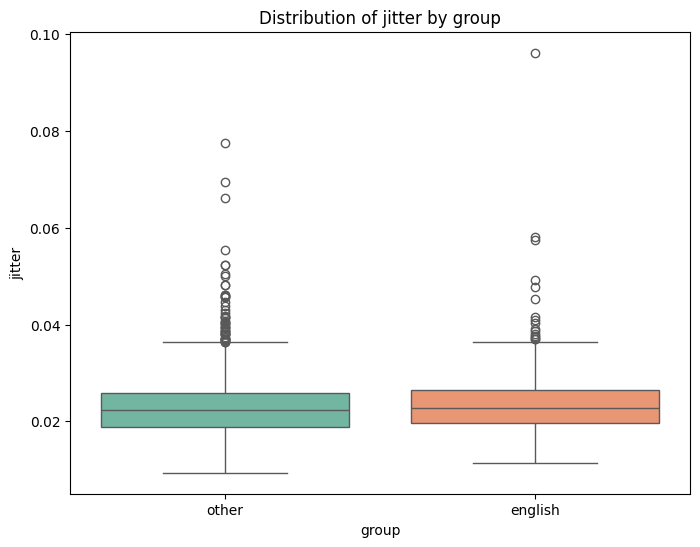

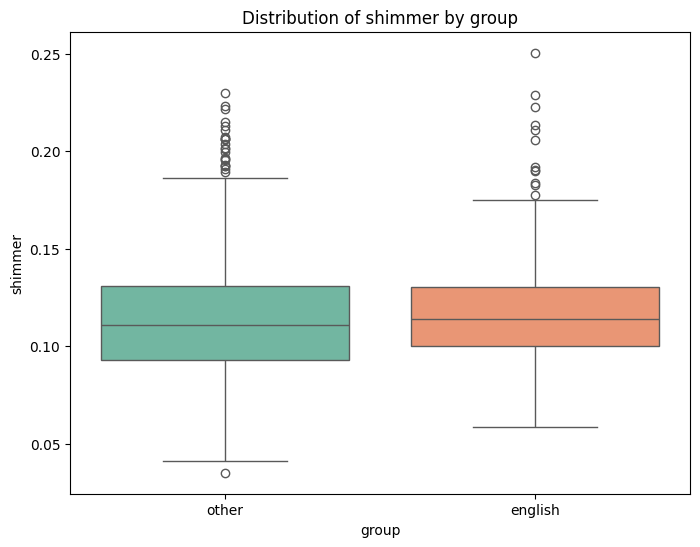

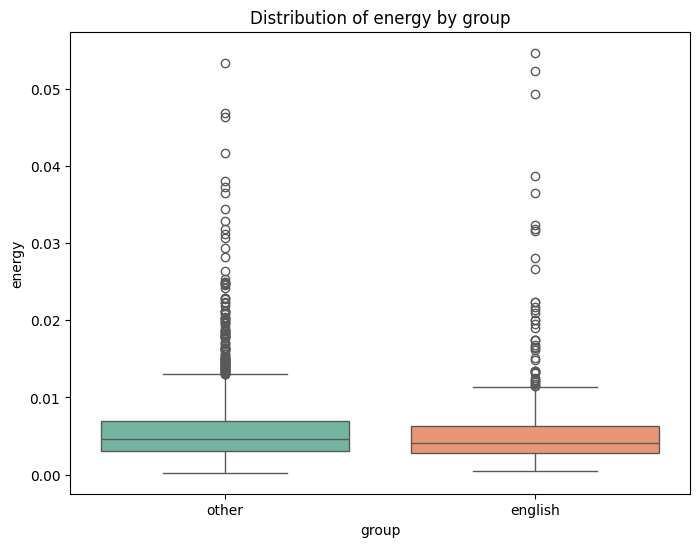

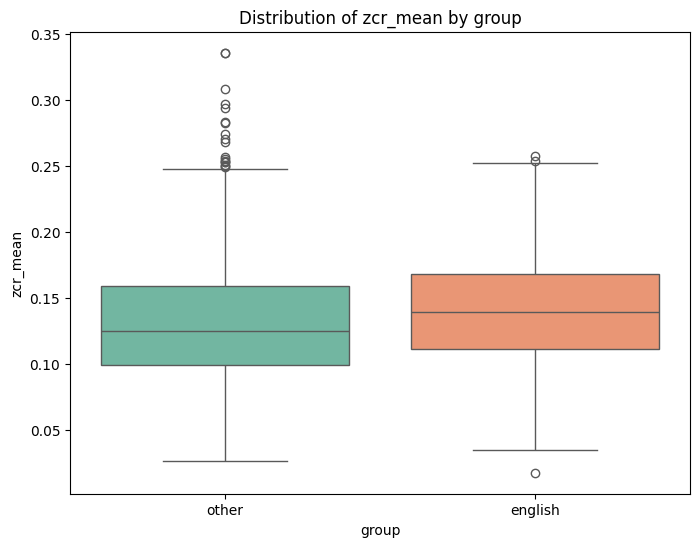

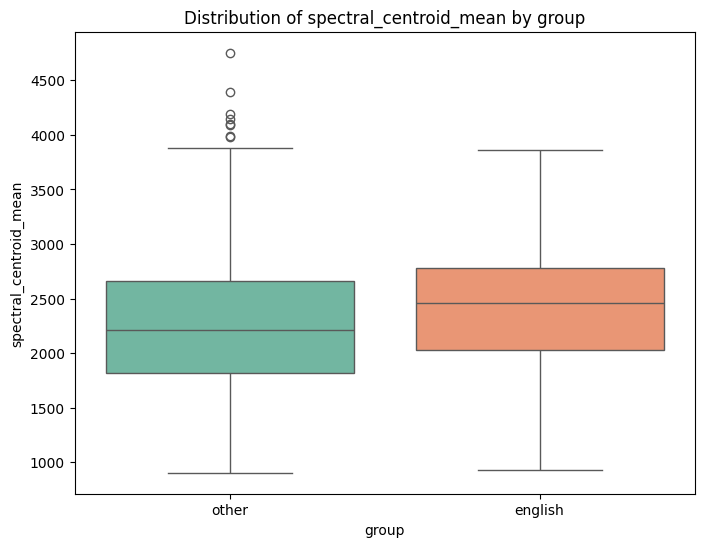

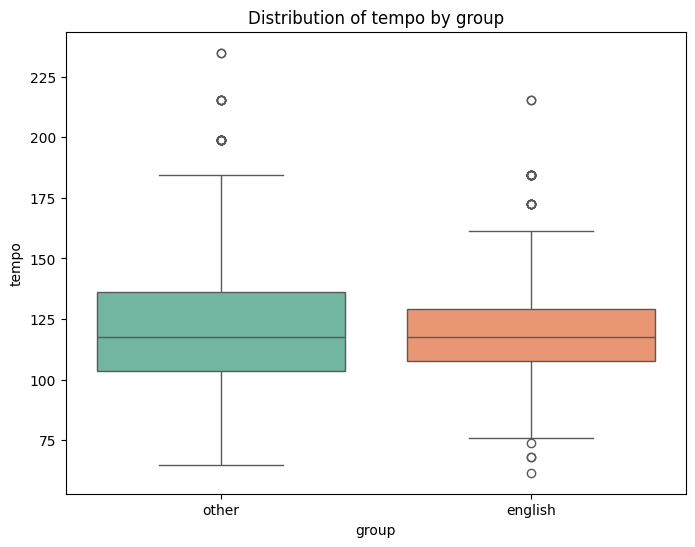

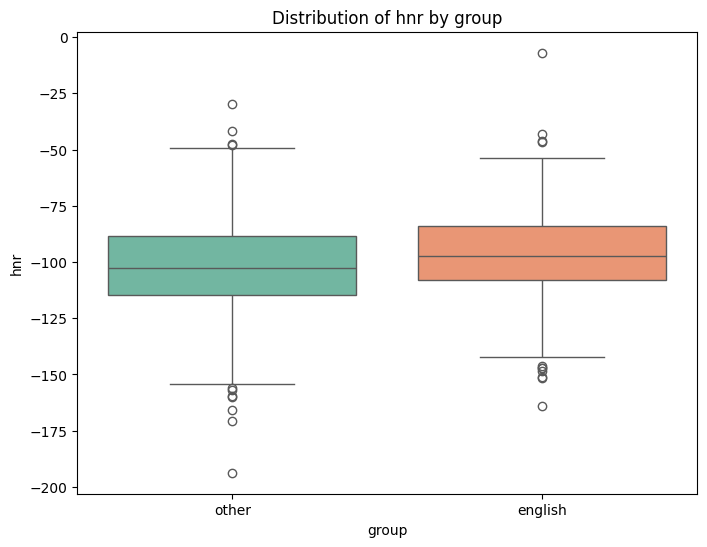

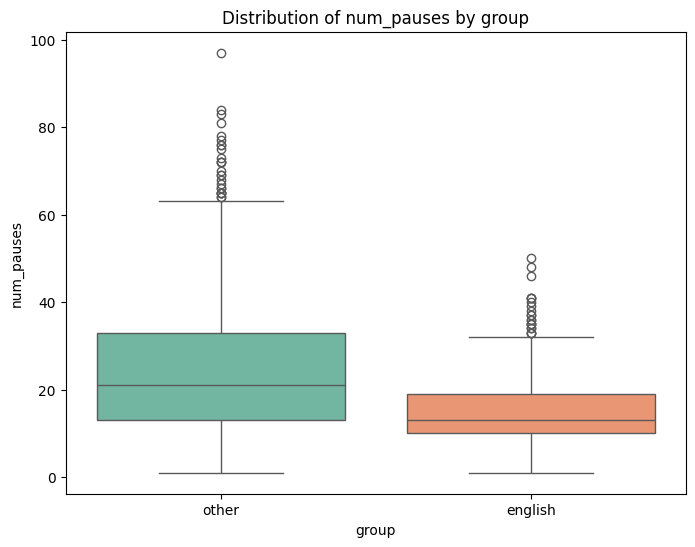

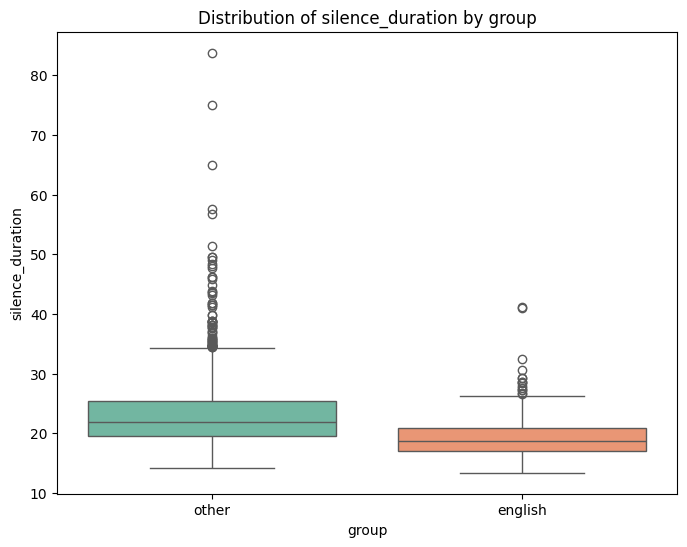

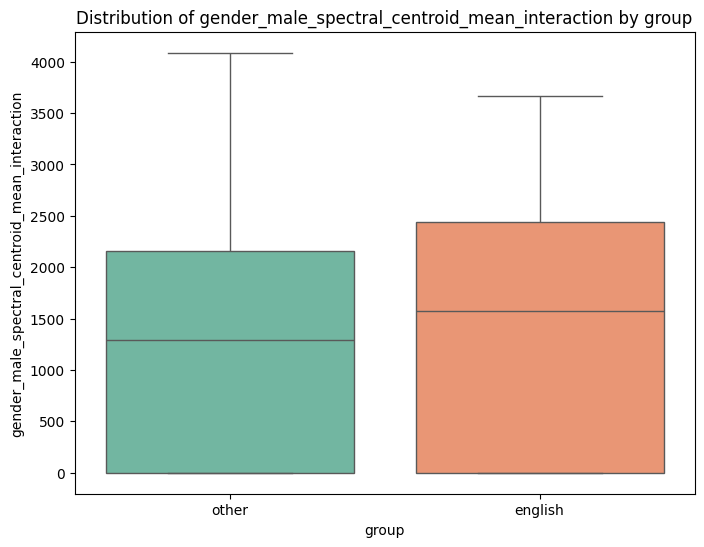

In [311]:
import seaborn as sns
import matplotlib.pyplot as plt

target = 'group'

for col in df_long.drop(columns=["num_words","num_characters"]).select_dtypes(include=['float', 'int']).columns:
    if col != 'age':  # Escludi l'età perché non ti interessa qui
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=df_long[target], y=df_long[col], hue=df_long["group"], palette='Set2')
        plt.title(f'Distribution of {col} by {target}')
        plt.show()


In [312]:
df_long = pd.get_dummies(df_long, columns=['group'])

In [313]:
df_long

,age,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration,path,gender_male_spectral_centroid_mean_interaction,group_english,group_other
Id,,,,,,,,,,,,,,,,,,,
0,24.0,1821.6906,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,151.999081,-123.999726,69,281,39,23.846893,audios_development/1.wav,0.000000,False,True
1,22.5,1297.8187,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,129.199219,-86.928478,69,281,21,19.388662,audios_development/2.wav,0.000000,False,True
2,22.0,1332.8524,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,117.453835,-98.450670,69,281,1,21.640998,audios_development/3.wav,0.000000,False,True
3,22.0,1430.3499,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,117.453835,-56.459762,69,281,9,19.644127,audios_development/4.wav,0.000000,True,False
4,22.0,1688.7234,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,112.347147,-80.349204,69,281,11,18.041905,audios_development/5.wav,1930.897375,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,NaN,1123.5277,3999.2878,145.67764,0.024933,0.120295,0.004035,0.099690,1739.753953,107.666016,-86.924431,69,281,12,22.325533,audios_evaluation/681.wav,0.000000,False,True
682,NaN,1154.8881,3999.3843,145.38353,0.017411,0.104561,0.005208,0.083461,1609.788624,161.499023,-108.645027,69,281,37,29.860862,audios_evaluation/683.wav,0.000000,False,True
684,NaN,1649.4945,3999.2605,145.48236,0.022151,0.093834,0.008115,0.134031,2086.253526,129.199219,-86.504716,69,281,16,19.504762,audios_evaluation/685.wav,2086.253526,False,True


In [314]:
group_cols = df_long.columns[df_long.columns.str.startswith('group_')]

In [315]:
for col in ['num_pauses','silence_duration']:
    for group in group_cols:
        df_long[f"{group}_{col}_interaction"] = df_long[group] * df_long[col]
df_long = df_long.drop(columns=group_cols)
df_long = df_long.drop(columns=df_long.columns[df_long.columns.str.startswith('group_english')])

In [316]:
df_long = df_long.drop(columns=['num_words','num_characters'])

In [317]:
df_long

,age,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_pauses,silence_duration,path,gender_male_spectral_centroid_mean_interaction,group_other_num_pauses_interaction,group_other_silence_duration_interaction
Id,,,,,,,,,,,,,,,,,
0,24.0,1821.6906,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,151.999081,-123.999726,39,23.846893,audios_development/1.wav,0.000000,39,23.846893
1,22.5,1297.8187,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,129.199219,-86.928478,21,19.388662,audios_development/2.wav,0.000000,21,19.388662
2,22.0,1332.8524,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,117.453835,-98.450670,1,21.640998,audios_development/3.wav,0.000000,1,21.640998
3,22.0,1430.3499,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,117.453835,-56.459762,9,19.644127,audios_development/4.wav,0.000000,0,0.000000
4,22.0,1688.7234,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,112.347147,-80.349204,11,18.041905,audios_development/5.wav,1930.897375,11,18.041905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,NaN,1123.5277,3999.2878,145.67764,0.024933,0.120295,0.004035,0.099690,1739.753953,107.666016,-86.924431,12,22.325533,audios_evaluation/681.wav,0.000000,12,22.325533
682,NaN,1154.8881,3999.3843,145.38353,0.017411,0.104561,0.005208,0.083461,1609.788624,161.499023,-108.645027,37,29.860862,audios_evaluation/683.wav,0.000000,37,29.860862
684,NaN,1649.4945,3999.2605,145.48236,0.022151,0.093834,0.008115,0.134031,2086.253526,129.199219,-86.504716,16,19.504762,audios_evaluation/685.wav,2086.253526,16,19.504762


## Correlations between features

In [318]:
# Long samples 

val_correlation= df_long.drop(columns="path").corr().abs()
triangular_mask = np.triu(np.ones(val_correlation.shape), k=1)
upper_triangle = val_correlation * triangular_mask
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]
high_corr_tuples = [(val_correlation.index[i], val_correlation.columns[j], upper_triangle.iloc[i, j])
                    for i in range(upper_triangle.shape[0])
                    for j in range(i + 1, upper_triangle.shape[1])
                    if upper_triangle.iloc[i, j] > 0.9 ]
print(f"Tuples of highly correlated features: {high_corr_tuples}")
print(f"Highly correlated features to be removed: {high_corr_features}")

Tuples of highly correlated features: []
Highly correlated features to be removed: []


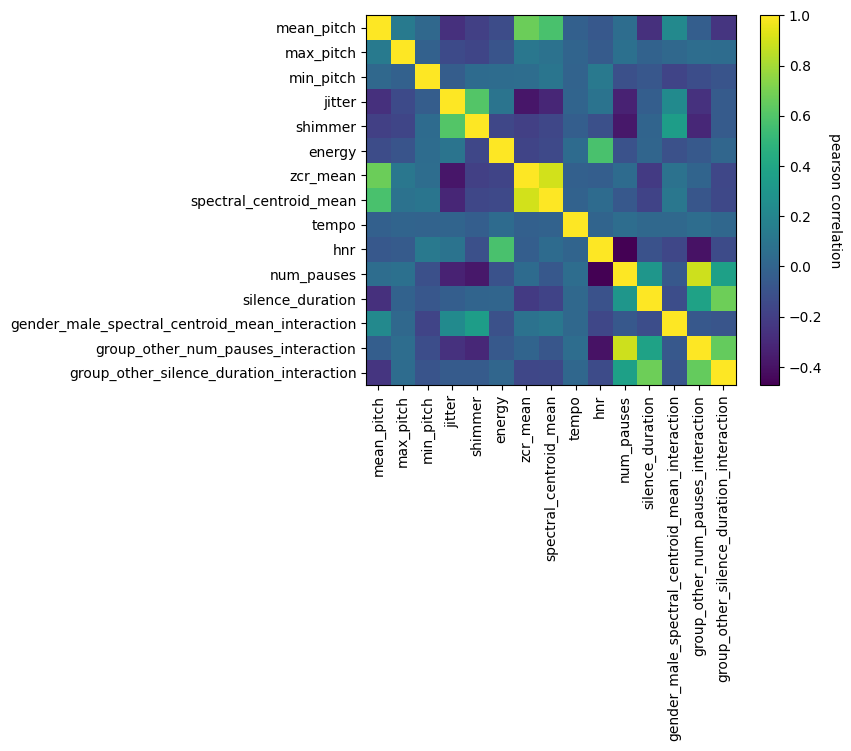

In [319]:
X = df_long.drop(columns=["age","path"])
new_correlation = X.corr()
fig, ax = plt.subplots()
im = ax.imshow(new_correlation)
ax.set_xticks(np.arange(new_correlation.columns.size))
ax.set_yticks(np.arange(new_correlation.columns.size))
ax.set_xticklabels(new_correlation.columns)
ax.set_yticklabels(new_correlation)
plt.setp(ax.get_xticklabels(), rotation=90, ha="right", va="center",
         rotation_mode="anchor")  # rotate labels on x-axis
cbar = ax.figure.colorbar(im, ax=ax)
_ = cbar.ax.set_ylabel('pearson correlation', rotation=-90, va="bottom")

In [320]:
# Short samples 

val_correlation= df_short.drop(columns="path").corr().abs()
triangular_mask = np.triu(np.ones(val_correlation.shape), k=1)
upper_triangle = val_correlation * triangular_mask
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]
high_corr_tuples = [(val_correlation.index[i], val_correlation.columns[j], upper_triangle.iloc[i, j])
                    for i in range(upper_triangle.shape[0])
                    for j in range(i + 1, upper_triangle.shape[1])
                    if upper_triangle.iloc[i, j] > 0.9]
print(f"Tuples of highly correlated features: {high_corr_tuples}")
print(f"Highly correlated features to be removed: {high_corr_features}")

df_short = df_short.drop(columns=high_corr_features)

Tuples of highly correlated features: [('num_words', 'num_characters', np.float64(0.9451231065838978))]
Highly correlated features to be removed: ['num_characters']


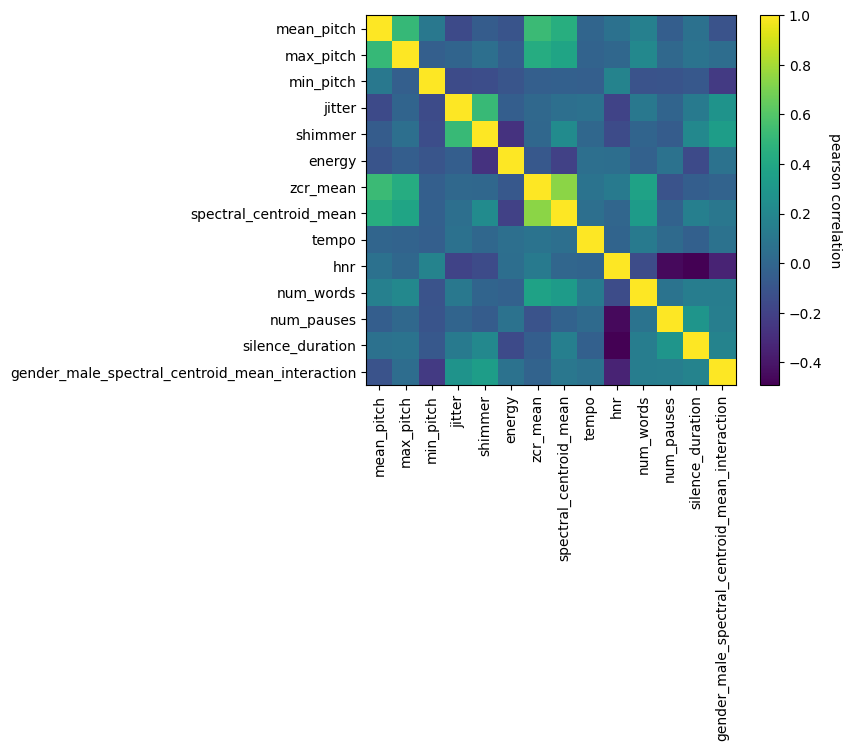

In [321]:
X = df_short.drop(columns=["age","path"])
new_correlation = X.corr()
fig, ax = plt.subplots()
im = ax.imshow(new_correlation)
ax.set_xticks(np.arange(new_correlation.columns.size))
ax.set_yticks(np.arange(new_correlation.columns.size))
ax.set_xticklabels(new_correlation.columns)
ax.set_yticklabels(new_correlation)
plt.setp(ax.get_xticklabels(), rotation=90, ha="right", va="center",
         rotation_mode="anchor")  # rotate labels on x-axis
cbar = ax.figure.colorbar(im, ax=ax)
_ = cbar.ax.set_ylabel('pearson correlation', rotation=-90, va="bottom")

# Models' parameters

In [322]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from prettytable import PrettyTable
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

In [323]:
degree=4
param_grid={
    'linreg':{},
    'ridge': {
        "ridge__alpha": [10, 15, 20],
        "ridge__random_state": [42]
    },
    'lasso':{
        "lasso__alpha": [0.05, 0.1, 0.5, 1],
        "lasso__max_iter":[10000],
        "lasso__random_state": [42]
    },
    'poly+linreg':{},
    'rf':{
        "n_estimators": [100, 200, 300,400,500,600],
        "random_state": [42],
        "n_jobs": [-1], # for parallelization
        "max_features": ["sqrt", "log2", None],
        
    }
    
}

In [324]:
models = {
    'linreg': make_pipeline(StandardScaler(), LinearRegression()),
    'ridge': make_pipeline(StandardScaler(), Ridge()),
    'lasso': make_pipeline(StandardScaler(), Lasso()),
    'rf': RandomForestRegressor(),
}

In [325]:
def evaluate_model(X_train,X_test, y_train,y_test, model, model_name):
    gs = GridSearchCV(model, param_grid[model_name], scoring="neg_root_mean_squared_error", cv=5)
    gs.fit(X_train, y_train)
    best_model=gs.best_estimator_
    print(gs.best_params_)
    y_hat = gs.predict(X_test)
    return root_mean_squared_error(y_test, y_hat),best_model

# Training and validation on the development set

## Short-samples

In [209]:
mask = ~df_short["age"].isna()
df_train_short = df_short[mask]

X = df_train_short.drop(columns=["age","path"])
y = df_train_short["age"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=42)

t = PrettyTable()
t.field_names = ['model', 'RMSE']
for name, model in models.items():
    print(f'Running {model}...')
    rmse, best_model = evaluate_model(X_train,X_test, y_train,y_test, model, name)
    t.add_row([name, rmse])
print(t)

Running Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])...
{}
Running Pipeline(steps=[('standardscaler', StandardScaler()), ('ridge', Ridge())])...
{'ridge__alpha': 20, 'ridge__random_state': 42}
Running Pipeline(steps=[('standardscaler', StandardScaler()), ('lasso', Lasso())])...
{'lasso__alpha': 0.1, 'lasso__max_iter': 10000, 'lasso__random_state': 42}
Running RandomForestRegressor()...
{'max_features': 'sqrt', 'n_estimators': 600, 'n_jobs': -1, 'random_state': 42}
+--------+-------------------+
| model  |        RMSE       |
+--------+-------------------+
| linreg | 4.437289755064323 |
| ridge  |  4.43543883954913 |
| lasso  | 4.425893089096994 |
|   rf   |  4.34976098476067 |
+--------+-------------------+


## Long-samples

In [80]:
mask = ~df_long["age"].isna()
df_train_long = df_long[mask]
X = df_train_long.drop(columns=["age","path"])
y = df_train_long["age"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=42)

t = PrettyTable()
t.field_names = ['model', 'RMSE']
for name, model in models.items():
    print(f'Running {model}...')
    rmse, best_model = evaluate_model(X_train,X_test, y_train,y_test, model, name)
    t.add_row([name, rmse])
print(t)

Running Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])...
{}
Running Pipeline(steps=[('standardscaler', StandardScaler()), ('ridge', Ridge())])...
{'ridge__alpha': 20, 'ridge__random_state': 42}
Running Pipeline(steps=[('standardscaler', StandardScaler()), ('lasso', Lasso())])...
{'lasso__alpha': 0.05, 'lasso__max_iter': 10000, 'lasso__random_state': 42}
Running RandomForestRegressor()...
{'max_features': 'sqrt', 'n_estimators': 500, 'n_jobs': -1, 'random_state': 42}
+--------+--------------------+
| model  |        RMSE        |
+--------+--------------------+
| linreg | 12.978939177383586 |
| ridge  | 12.974241385022209 |
| lasso  | 12.99636140946854  |
|   rf   | 13.020450823237685 |
+--------+--------------------+


In [326]:
mel_list=[20,30,40,50,60]
rmse_results_all = {}
for n_mel in mel_list:
    print(f'n_mel={n_mel}')
    df_audio = extract_audio_features(df_train_long,'dev','mel',n_mel,padding=True)
    df_train_long_audio = df_train_long.merge(df_audio, left_index=True, right_index=True, how="left")
    df_train_long_audio = df_train_long_audio.drop(columns="path")
    
    X = df_train_long_audio.drop(columns=["age"])
    y = df_train_long_audio["age"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=42)
    rmse_results = {}
    t = PrettyTable()
    t.field_names = ['model', 'RMSE']
    for name, model in models.items():
        print(f'Running {model}...')
        rmse, best_model = evaluate_model(X_train,X_test, y_train,y_test, model, name)
        rmse_results[name] = rmse
        t.add_row([name, rmse])
    rmse_results_all[n_mel] = rmse_results
    print(t)


n_mel=20
Loading existing features from audio_features/dev/features_mel_20_padding.csv...
Running Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])...
{}
Running Pipeline(steps=[('standardscaler', StandardScaler()), ('ridge', Ridge())])...
{'ridge__alpha': 20, 'ridge__random_state': 42}
Running Pipeline(steps=[('standardscaler', StandardScaler()), ('lasso', Lasso())])...
{'lasso__alpha': 0.1, 'lasso__max_iter': 10000, 'lasso__random_state': 42}
Running RandomForestRegressor()...
{'max_features': None, 'n_estimators': 400, 'n_jobs': -1, 'random_state': 42}
+--------+--------------------+
| model  |        RMSE        |
+--------+--------------------+
| linreg | 12.908461377317078 |
| ridge  | 12.618820603295426 |
| lasso  | 12.784930539815337 |
|   rf   | 13.156182454540573 |
+--------+--------------------+
n_mel=30
Loading existing features from audio_features/dev/features_mel_30_padding.csv...
Running Pipeline(steps=[('sta

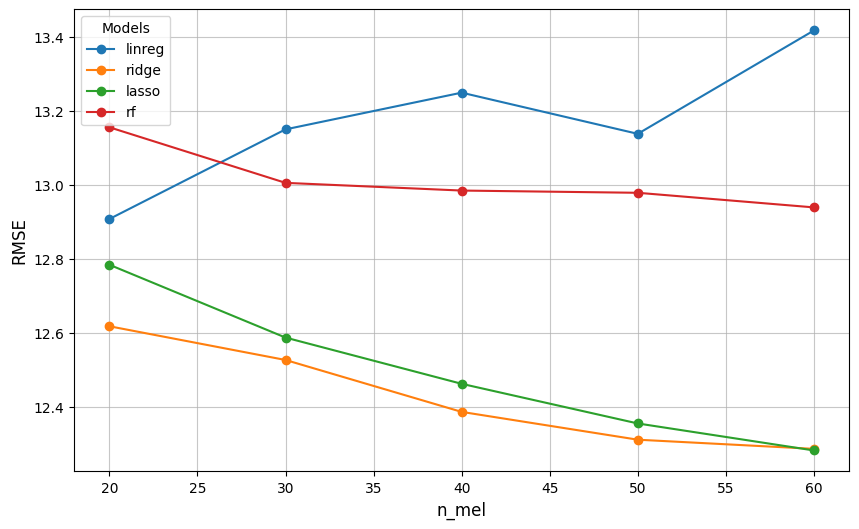

In [327]:
n_mel_values = list(rmse_results_all.keys())
model_names = list(models.keys())

plt.figure(figsize=(10, 6))
for model in model_names:
    rmse_values = [rmse_results_all[n_mel][model] for n_mel in n_mel_values]
    plt.plot(n_mel_values, rmse_values, marker='o', label=model)

plt.xlabel("n_mel", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.legend(title="Models", fontsize=10)
plt.grid(True, alpha=0.7)
plt.savefig("grafico_mel.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

In [328]:
mfcc_list=[10,11,12,13,14,15]
rmse_results_all = {}
for n_mfcc in mfcc_list:
    print(f'n_mfcc={n_mfcc}')
    df_audio = extract_audio_features(df_train_long,'dev','mfcc',n_mfcc,padding=True)
    df_train_long_audio = df_train_long.merge(df_audio, left_index=True, right_index=True, how="left")
    df_train_long_audio = df_train_long_audio.drop(columns="path")
    
    X = df_train_long_audio.drop(columns=["age"])
    y = df_train_long_audio["age"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=42)
    rmse_results = {}
    t = PrettyTable()
    t.field_names = ['model', 'RMSE']
    for name, model in models.items():
        print(f'Running {model}...')
        rmse, best_model = evaluate_model(X_train,X_test, y_train,y_test, model, name)
        rmse_results[name] = rmse
        t.add_row([name, rmse])
    rmse_results_all[n_mfcc] = rmse_results
    print(t)

n_mfcc=10
Loading existing features from audio_features/dev/features_mfcc_10_padding.csv...
Running Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])...
{}
Running Pipeline(steps=[('standardscaler', StandardScaler()), ('ridge', Ridge())])...
{'ridge__alpha': 20, 'ridge__random_state': 42}
Running Pipeline(steps=[('standardscaler', StandardScaler()), ('lasso', Lasso())])...
{'lasso__alpha': 0.05, 'lasso__max_iter': 10000, 'lasso__random_state': 42}
Running RandomForestRegressor()...
{'max_features': None, 'n_estimators': 500, 'n_jobs': -1, 'random_state': 42}
+--------+--------------------+
| model  |        RMSE        |
+--------+--------------------+
| linreg | 12.607289869247243 |
| ridge  | 12.552196448764354 |
| lasso  | 12.59034228173029  |
|   rf   | 12.767598528851273 |
+--------+--------------------+
n_mfcc=11
Loading existing features from audio_features/dev/features_mfcc_11_padding.csv...
Running Pipeline(steps=[

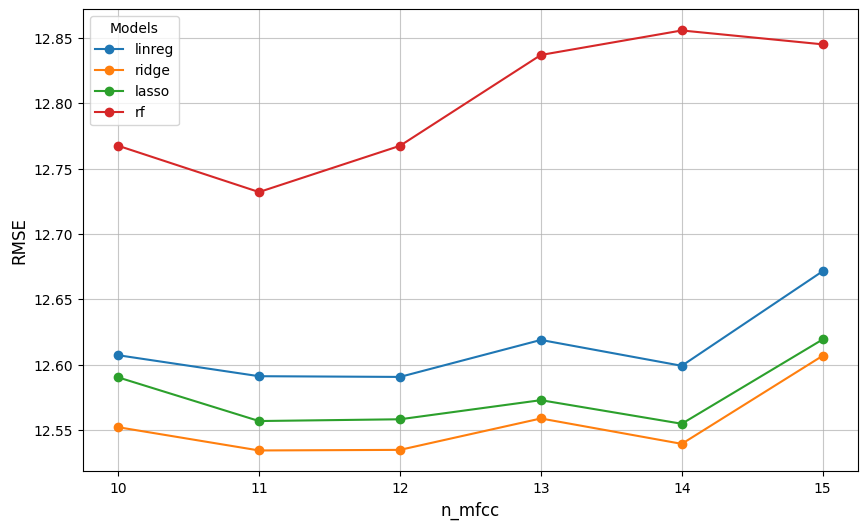

In [329]:
n_mfcc_values = list(rmse_results_all.keys())
model_names = list(models.keys())

plt.figure(figsize=(10, 6))
for model in model_names:
    rmse_values = [rmse_results_all[n_mfcc][model] for n_mfcc in mfcc_list]
    plt.plot(n_mfcc_values, rmse_values, marker='o', label=model)

plt.xlabel("n_mfcc", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.legend(title="Models", fontsize=10)
plt.grid(True, alpha=0.7)
plt.savefig("grafico_mfcc.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

### Validation on rf (short) + lasso (long)

In [330]:
# short
mask = ~df_short["age"].isna()
df_train_short = df_short[mask]
X = df_train_short.drop(columns=["age", "path"])
y = df_train_short["age"]
X_train, X_test, y_train, y_test_short = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

model = RandomForestRegressor(max_features='sqrt', n_estimators=600, random_state=42)
model.fit(X_train, y_train)
predicted_ages_short = model.predict(X_test)

y_short = pd.DataFrame({
    'Id': X_test.index,
    'Predicted': predicted_ages_short
})

# long
df_audio = extract_audio_features(df_train_long, 'dev', "mel", 60)
df_train_long_audio = df_train_long.merge(df_audio, left_index=True, right_index=True, how="left")

X = df_train_long_audio.drop(columns=["age", "path"])
y = df_train_long_audio["age"]
X_train, X_test, y_train, y_test_long = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

model = make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=10000))
model.fit(X_train, y_train)
predicted_ages_long = model.predict(X_test)

y_long = pd.DataFrame({
    'Id': X_test.index,
    'Predicted': predicted_ages_long
})

y_pred_all = pd.concat([y_short, y_long])
y_test_all = pd.concat([y_test_short, y_test_long])

rmse = root_mean_squared_error(y_test_all.values, y_pred_all["Predicted"])
print("RMSE:", rmse)

Loading existing features from audio_features/dev/features_mel_60_padding.csv...
RMSE: 9.527654305626319


In [331]:
y_pred_all.set_index('Id',inplace=True)

Plot of the residuals

In [332]:
residuals = y_pred_all['Predicted']-y_test_all 

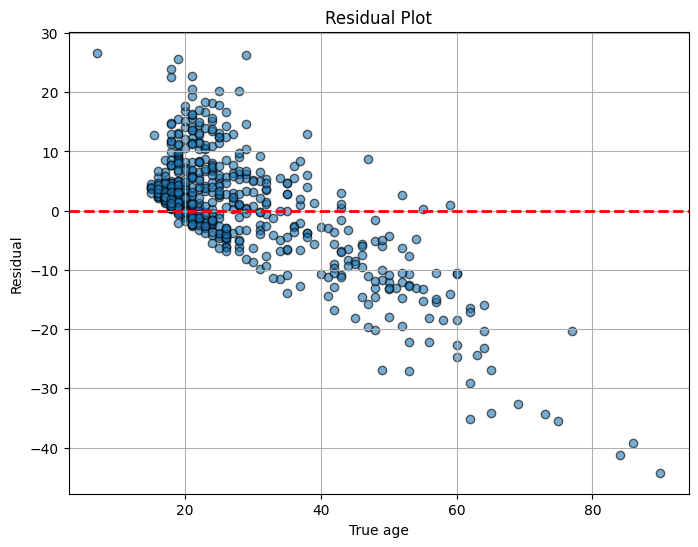

In [333]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_all, residuals, alpha=0.6, edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('True age')
plt.ylabel('Residual')
plt.grid(True)
plt.savefig("res_vs_true.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

### Validation on rf (short) + rf with feature removals (long)

In [335]:
def test_best_model(df):
    X=df.drop(columns=["age"]).values
    y=df['age'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=42)

    model=Lasso(alpha=0.1, max_iter=10000)
    model.fit(X_train, y_train)
    print("RMSE", root_mean_squared_error(y_test, model.predict(X_test)))
    
    return model, y_test, model.predict(X_test)

In [336]:
model, y_test, y_pred = test_best_model(df_train_long_audio.drop(columns="path"))
coefficients = model.coef_
feature_names = X.columns if isinstance(X, pd.DataFrame) else [f"Feature_{i}" for i in range(X.shape[1])]
zero_coeff_features = [feature for coef, feature in zip(coefficients, feature_names) if coef == 0]
important_coeff_features = [feature for coef, feature in zip(coefficients, feature_names) if coef != 0]

RMSE 12.48240332018468


In [337]:
zero_coeff_features

['min_pitch',
 'jitter',
 'shimmer',
 'energy',
 'zcr_mean',
 'std_spect_7',
 'mean_spect_9',
 'std_spect_9',
 'mean_spect_10',
 'mean_spect_11',
 'std_spect_12',
 'mean_spect_13',
 'std_spect_14',
 'mean_spect_15',
 'mean_spect_17',
 'mean_spect_18',
 'std_spect_19',
 'mean_spect_20',
 'std_spect_20',
 'mean_spect_22',
 'mean_spect_23',
 'std_spect_23',
 'mean_spect_25',
 'mean_spect_26',
 'std_spect_26',
 'mean_spect_27',
 'std_spect_27',
 'mean_spect_28',
 'std_spect_28',
 'mean_spect_29',
 'mean_spect_30',
 'mean_spect_32',
 'std_spect_32',
 'std_spect_33',
 'mean_spect_34',
 'std_spect_35',
 'mean_spect_36',
 'mean_spect_37',
 'std_spect_37',
 'mean_spect_38',
 'mean_spect_39',
 'std_spect_39',
 'std_spect_40',
 'std_spect_41',
 'mean_spect_42',
 'std_spect_43',
 'mean_spect_44',
 'std_spect_45',
 'mean_spect_46',
 'std_spect_47',
 'mean_spect_48',
 'std_spect_49',
 'mean_spect_50',
 'mean_spect_52',
 'std_spect_52',
 'mean_spect_55',
 'std_spect_55',
 'mean_spect_56',
 'mean_spec

In [338]:
df_audio = extract_audio_features(df_train_long,'dev','mel',60,padding=True)
df_train_long_audio = df_train_long.merge(df_audio, left_index=True, right_index=True, how="left")
df_to_use = df_train_long_audio.drop(columns=zero_coeff_features)
X = df_to_use.drop(columns=['age','path']).values
y = df_to_use['age'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=42)
t = PrettyTable()
t.field_names = ['model', 'RMSE']
for name, model in models.items():
    print(f'Running {model}...')
    rmse, best_model = evaluate_model(X_train,X_test, y_train,y_test, model, name)
    rmse_results[name] = rmse
    t.add_row([name, rmse])
print(t)


Loading existing features from audio_features/dev/features_mel_60_padding.csv...
Running Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])...
{}
Running Pipeline(steps=[('standardscaler', StandardScaler()), ('ridge', Ridge())])...
{'ridge__alpha': 20, 'ridge__random_state': 42}
Running Pipeline(steps=[('standardscaler', StandardScaler()), ('lasso', Lasso())])...
{'lasso__alpha': 0.1, 'lasso__max_iter': 10000, 'lasso__random_state': 42}
Running RandomForestRegressor()...
{'max_features': None, 'n_estimators': 400, 'n_jobs': -1, 'random_state': 42}
+--------+--------------------+
| model  |        RMSE        |
+--------+--------------------+
| linreg | 12.71589273360987  |
| ridge  | 12.412227724248119 |
| lasso  | 12.411657614464604 |
|   rf   | 12.797630008651874 |
+--------+--------------------+


In [339]:
# short
mask = ~df_short["age"].isna()
df_train_short = df_short[mask]
X = df_train_short.drop(columns=["age", "path"])
y = df_train_short["age"]
X_train, X_test, y_train, y_test_short = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

model = RandomForestRegressor(max_features='sqrt', n_estimators=600, random_state=42)
model.fit(X_train, y_train)
predicted_ages_short = model.predict(X_test)

y_short = pd.DataFrame({
    'Id': X_test.index,
    'Predicted': predicted_ages_short
})

# long
df_audio = extract_audio_features(df_train_long,'dev','mel',60,padding=True)
df_train_long_audio = df_train_long.merge(df_audio, left_index=True, right_index=True, how="left")
df_to_use = df_train_long_audio.drop(columns=zero_coeff_features)
X = df_to_use.drop(columns=['age','path'])
y = df_to_use['age']
X_train, X_test, y_train, y_test_long = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

model = RandomForestRegressor(max_features= None, n_estimators= 400,random_state= 42)
model.fit(X_train, y_train)
predicted_ages_long = model.predict(X_test)

y_long = pd.DataFrame({
    'Id': X_test.index,
    'Predicted': predicted_ages_long
})

y_pred_all = pd.concat([y_short, y_long])
y_test_all = pd.concat([y_test_short, y_test_long])

rmse = root_mean_squared_error(y_test_all.values, y_pred_all["Predicted"])
print("RMSE:", rmse)


Loading existing features from audio_features/dev/features_mel_60_padding.csv...
RMSE: 10.20451582641942


# Evaluation

## Evaluation of rf (short) + lasso (long)

In [340]:
mask = ~df_short["age"].isna()
X = df_short.drop(columns=["age","path"])
y = df_short["age"]
X_train = X[mask]
y_train = y[mask]
X_eval = X[~mask]

# Best model
model = RandomForestRegressor(max_features='sqrt', n_estimators=600, random_state=42)

model.fit(X_train, y_train)
predicted_ages = model.predict(X_eval)

predicted_ages = [age for age in predicted_ages]

# Create the submission file
submission_df_short = pd.DataFrame({
    'Id': X_eval.index,
    'Predicted': predicted_ages
})


In [341]:
mask = ~df_long["age"].isna()
df_train_long = df_long[mask]
df_audio = extract_audio_features(df_train_long,'dev','mel',60,padding=True)
df_train_long_audio = df_train_long.merge(df_audio, left_index=True, right_index=True, how="left")

df_eval = df_long[~mask]
df_audio_eval = extract_audio_features(df_eval,'eval','mel',60, padding=True)
df_eval_long_audio = df_eval.merge(df_audio_eval, left_index=True, right_index=True, how="left")

df = pd.concat([df_train_long_audio, df_eval_long_audio], sort=False)

X = df.drop(columns=["age","path"])
y = df["age"]
X_train = X[mask]
y_train = y[mask]
X_eval = X[~mask]

# Best model
model = make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=10000))

model.fit(X_train, y_train)
predicted_ages = model.predict(X_eval)

predicted_ages = [age for age in predicted_ages]

# Create the submission file
submission_df_long_lasso = pd.DataFrame({
    'Id': X_eval.index,
    'Predicted': predicted_ages
})

Loading existing features from audio_features/dev/features_mel_60_padding.csv...
Loading existing features from audio_features/eval/features_mel_60_padding.csv...


In [342]:
submission_df = pd.concat([submission_df_short, submission_df_long_lasso])  
submission_df = submission_df.sort_values(by='Id')  

In [343]:
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S_rf_lasso")  
submission_file = f"submission_{timestamp}.csv"
submission_df.to_csv(submission_file, index=False)

print(f"Submission file created: {submission_file}")

Submission file created: submission_20250128_221920_rf_lasso.csv


## Evaluation on rf (short) + rf with feature important (long)

In [344]:
mask = ~df_long["age"].isna()
df_train_long = df_long[mask]
df_audio = extract_audio_features(df_train_long,'dev','mel',60,padding=True)
df_train_long_audio = df_train_long.merge(df_audio, left_index=True, right_index=True, how="left")
df_train_long_audio = df_train_long_audio.drop(columns=zero_coeff_features)

df_eval = df_long[~mask]
df_audio_eval = extract_audio_features(df_eval,'eval','mel',60, padding=True)
df_eval_long_audio = df_eval.merge(df_audio_eval, left_index=True, right_index=True, how="left")
df_eval_long_audio = df_eval_long_audio.drop(columns=zero_coeff_features)

df = pd.concat([df_train_long_audio, df_eval_long_audio], sort=False)

Loading existing features from audio_features/dev/features_mel_60_padding.csv...
Loading existing features from audio_features/eval/features_mel_60_padding.csv...


In [345]:
X = df.drop(columns=["age","path"])
y = df["age"]
X_train = X[mask]
y_train = y[mask]
X_eval = X[~mask]

# Best model
model = RandomForestRegressor(max_features=None, n_estimators=400, random_state=42)

model.fit(X_train, y_train)
predicted_ages = model.predict(X_eval)

predicted_ages = [age for age in predicted_ages]

# Create the submission file
submission_df_long_rf = pd.DataFrame({
    'Id': X_eval.index,
    'Predicted': predicted_ages
})

In [346]:
submission_df = pd.concat([submission_df_short, submission_df_long_rf])  
submission_df = submission_df.sort_values(by='Id') 

In [347]:
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S_rf_rf_feature_importance")  
submission_file = f"submission_{timestamp}.csv"
submission_df.to_csv(submission_file, index=False)

print(f"Submission file created: {submission_file}")

Submission file created: submission_20250128_222040_rf_rf_feature_importance.csv
